# This is a classification project where we use many tools for Mchine Learning and Data science.
## 1. Project defination:
This is Heart disease predection model that prediects wather or not a persion has Heart disease based on   his/her clinical information.

## 2. Data:
The original data came from the Cleavland database from the UCI Machine Learning Repository.
https://archive.ics.uci.edu/dataset/45/heart+disease

There is allso a version available on Kaggle.
https://www.kaggle.com/datasets/hamnawaseem112222222/uci-heart-disease-dataset

### Additional Information:

This database contains 76 attributes, but all published experiments refer to using a subset of 14 of them.  In particular, the Cleveland database is the only one that has been used by ML researchers to date.  The "goal" field refers to the presence of heart disease in the patient.  It is integer valued from 0 (no presence) to 4. Experiments with the Cleveland database have concentrated on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0).


* age : Age of the patient in years
* sex : Gender — 1 = Male, 0 = Female
* cp : Chest pain type — 1=Typical angina, 2=Atypical angina,
3=Non-anginal pain, 4=Asymptomatic
* trestbps : Resting blood pressure in mm Hg
* chol : Serum cholesterol in mg/dl
* fbs : Fasting blood sugar > 120 mg/dl — 1=True, 0=False
* restecg : Resting ECG results — 0=Normal, 1=ST-T abnormality,
2=Left ventricular hypertrophy
* thalach : Maximum heart rate achieved
* exang : Exercise induced angina — 1=Yes, 0=No
* oldpeak : ST depression induced by exercise relative to rest
* slope : Slope of peak exercise ST segment —
1=Upsloping, 2=Flat, 3=Downsloping
* ca : Number of major vessels colored by fluoroscopy (0–3)
* thal : Thalassemia — 3=Normal, 6=Fixed defect, 7=Reversible defect
* target : 0 = No Heart Disease, 1 = Heart Disease


## 3. Evaluation:
Testing wathe or not a person has Heart disease with 85% or over accurecy.

## 4. Featuring:
Geting more infromation about our data based on some researches and doing analysis on our dataset. Findeing some putterns and information about our dataset and features on our data.

## 5. Modeling:
Findeing the best algorithms for training our Model based on our dataset

In [13]:
# Data analysis and ploting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# we want our plots to appear inside our notebook
%matplotlib inline
# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
# saving models
import pickle

## 4. Featuring
### Load Data 
Geting familiar with our data and Do sum analysis on our data

In [2]:
# Loading Data
df = pd.read_csv("sk-data/heart-disease.csv")
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


Text(0, 0.5, 'Amount')

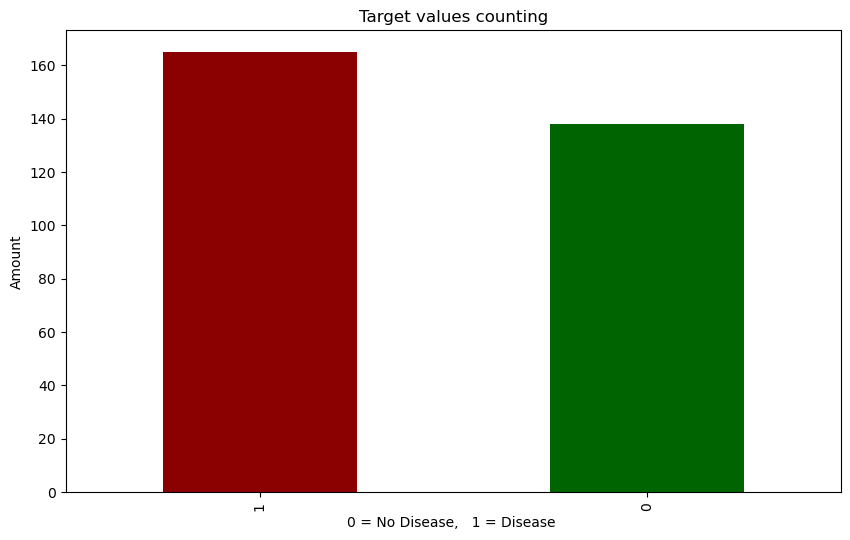

In [43]:
df["target"].value_counts().plot(kind="bar", figsize = (10,6) ,color=["darkred", "darkgreen"]);
plt.title("Target values counting")
plt.xlabel("0 = No Disease,   1 = Disease ")
plt.ylabel("Amount")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
# Is there any missing value data?
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


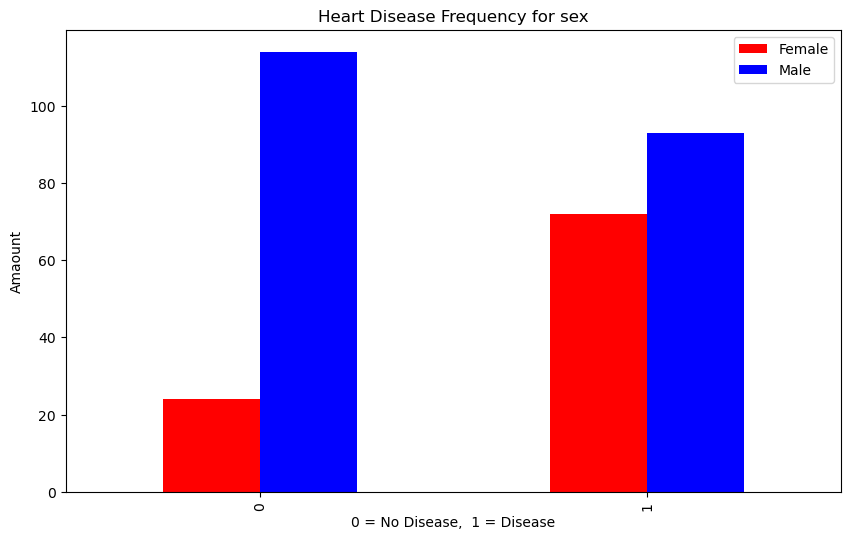

In [11]:
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                   figsize=(10, 6),
                                   color=["Red", "Blue"])
plt.title("Heart Disease Frequency for sex")
plt.xlabel("0 = No Disease,  1 = Disease")
plt.ylabel("Amaount")
plt.legend(["Female", "Male"])

In [12]:
pd.crosstab(df.target, df.fbs)

fbs,0,1
target,,
0,116,22
1,142,23


Text(0, 0.5, 'Aamount')

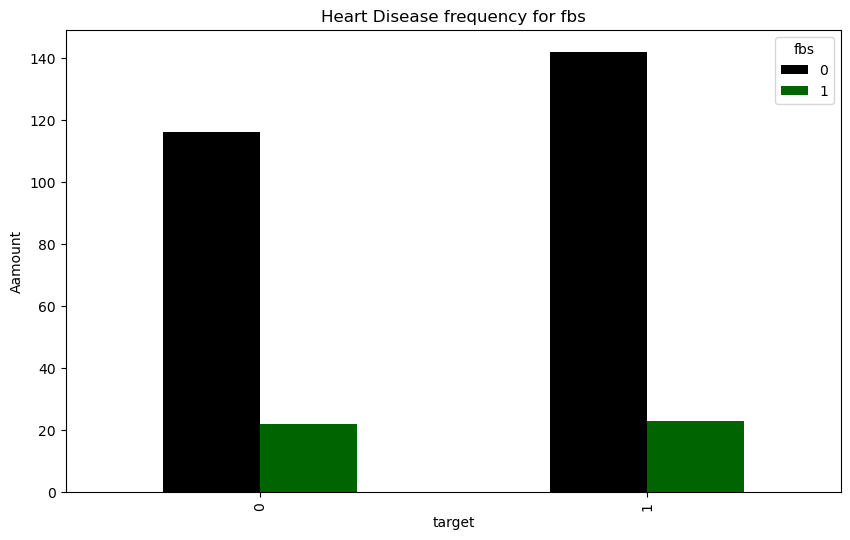

In [13]:
pd.crosstab(df.target, df.fbs).plot(kind="bar", figsize=(10,6),
                                   color=["black", "Darkgreen"])
plt.title("Heart Disease frequency for fbs")
plt.ylabel("Aamount")

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<Axes: ylabel='Frequency'>

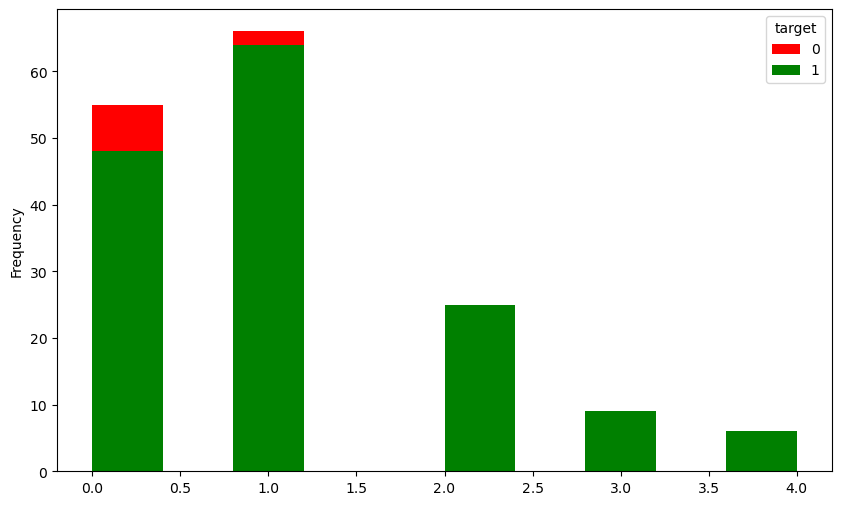

In [14]:
pd.crosstab(df.chol, df.target).plot(kind="hist",
                                      color=["Red", "Green"],
                                    figsize = (10, 6))

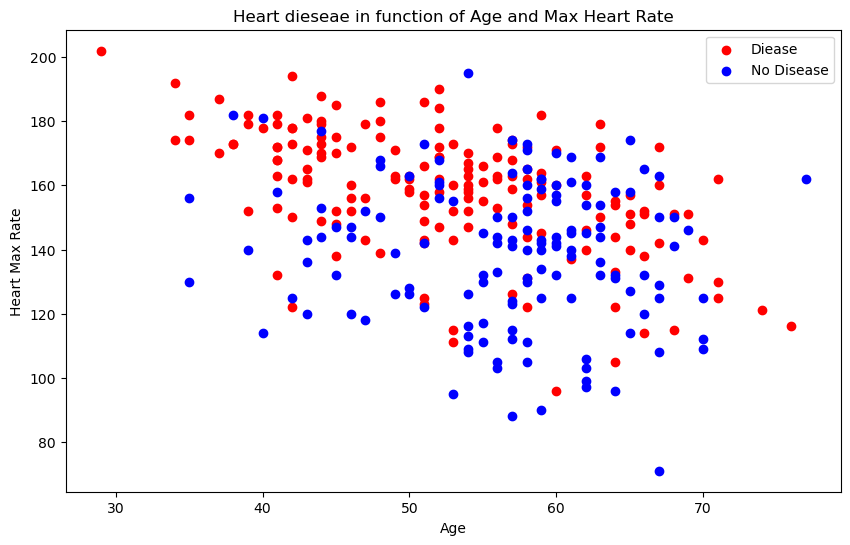

In [14]:
# Analysing the Heart disease based on Age and Max Heart Rate of the sampels.
plt.figure(figsize=(10,6))
plt.scatter(df.age[df.target==1],
           df.thalach[df.target==1],
           c="red")
plt.scatter(df.age[df.target==0],
           df.thalach[df.target==0],
           c="blue")
plt.title("Heart dieseae in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Heart Max Rate")
plt.legend(["Diease", "No Disease"])

In [15]:
# Analysing the Heart disease based on the chest pain type of the sumples
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


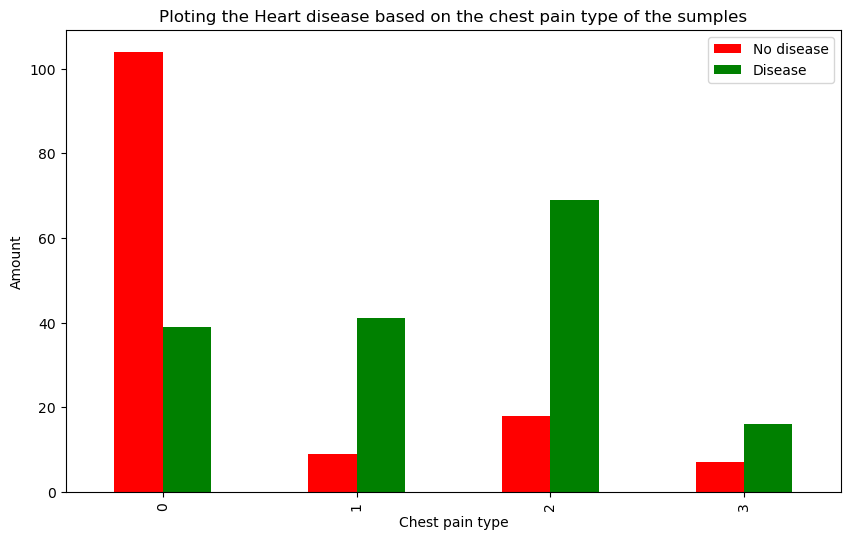

In [16]:
pd.crosstab(df.cp, df.target).plot(kind="bar",
                                  figsize=(10,6),
                                  color=["Red", "Green"])
plt.title("Ploting the Heart disease based on the chest pain type of the sumples")
plt.xlabel("Chest pain type")
plt.ylabel("Amount")
plt.legend(["No disease", "Disease"])

## .5 Modeling
Defineing the x and y (Features and Labels) and spliting our data into training and testing parts.

In [3]:
# Defineing the x and y (Features and Labels).
np.random.seed(42)
x = df.drop("target", axis=1)
y = df["target"]
# Spliting the training and testing data with train_test_split.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

### Training
Now that our x and y are defined and our data splited for training and testing, it's time to find the best algorithm for training our model and solving the problem.
we will use 3 deffrent sklearn models for training our model.
1. RandomForrestClassifier
2. KNeighborsClassifier
3. LogisticRegression

In [4]:
np.random.seed(4327)
models = {"LogisticRegression": LogisticRegression(max_iter=5000),
         "Random Forrest": RandomForestClassifier(),
         "KNN": KNeighborsClassifier(n_neighbors=11)}
for name, model in models.items():
    model.fit(x_train, y_train)

In [5]:
lis = {}
for name, model in models.items():
    lis[name] = model.score(x_test, y_test)
lis

{'LogisticRegression': 0.8852459016393442,
 'Random Forrest': 0.8360655737704918,
 'KNN': 0.7540983606557377}

### Hyperparameter Tuning
KNN tuning

In [6]:
train_score = []
test_score = []
neighbors = range(3,21)
knn = KNeighborsClassifier()
for i in neighbors:
    knn.set_params(n_neighbors=i)
    knn.fit(x_train, y_train)
    train_score.append(knn.score(x_train, y_train))
    test_score.append(knn.score(x_test, y_test))
train_score

[0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

In [68]:
test_score

[0.6229508196721312,
 0.639344262295082,
 0.6557377049180327,
 0.6721311475409836,
 0.6885245901639344,
 0.7213114754098361,
 0.7049180327868853,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.7540983606557377,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.6885245901639344,
 0.7213114754098361,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.6557377049180327]

## Ploting the Accurecy Graph of KNN tuning

The highest KNN Accurecy in test data is 75.41%


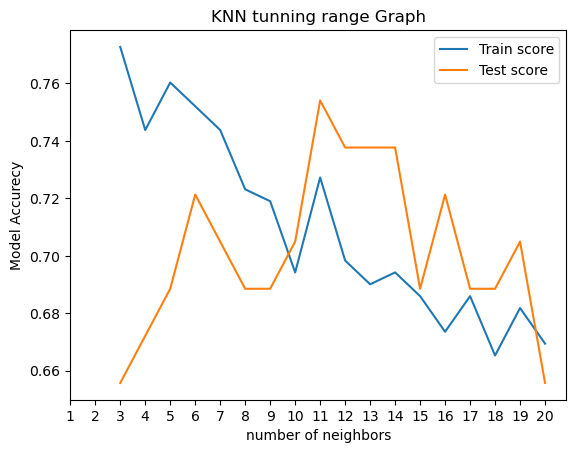

In [7]:
plt.plot(neighbors, train_score, label="Train score")
plt.plot(neighbors, test_score, label="Test score")
plt.xticks(np.arange(1,21,1))
plt.title("KNN tunning range Graph")
plt.xlabel("number of neighbors")
plt.ylabel("Model Accurecy")
plt.legend()
print(f"The highest KNN Accurecy in test data is {max(test_score)*100:.2f}%")

## Evaluating our model

In [7]:
# Score
lis

{'Logistic Regression': 0.8852459016393442,
 'Random Forrest': 0.8360655737704918,
 'KNN': 0.7540983606557377}

In [7]:
# Cross_val_score
a = cross_val_score(RandomForestClassifier(), x, y, cv=5)
b = cross_val_score(LogisticRegression(max_iter=5000), x, y, cv=5)
c = cross_val_score(KNeighborsClassifier(n_neighbors=12), x, y, cv=5)
lis = {"RandomForrest": a.mean(),
      "LogisticRegression": b.mean(),
      "KNN": c.mean()}
lis

{'RandomForrest': 0.8215846994535518,
 'LogisticRegression': 0.8282513661202187,
 'KNN': 0.6601092896174864}

In [18]:
# roc_curve
y_probs1 = models["LogisticRegression"].predict_proba(x_test)
y_probs2 = models["Random Forrest"].predict_proba(x_test)
y_probs3 = models["KNN"].predict_proba(x_test)
y_probs_positive1 = y_probs1[:,1]
y_probs_positive2 = y_probs2[:,1]
y_probs_positive3 = y_probs3[:,1]

In [20]:
# roc_curve on LogisticRegression
fpr1, tpr1, tresholds1 = roc_curve(y_test, y_probs_positive1)
fpr1

array([0.        , 0.        , 0.        , 0.03448276, 0.03448276,
       0.06896552, 0.06896552, 0.10344828, 0.10344828, 0.13793103,
       0.13793103, 0.20689655, 0.20689655, 0.37931034, 0.37931034,
       0.4137931 , 0.4137931 , 1.        ])

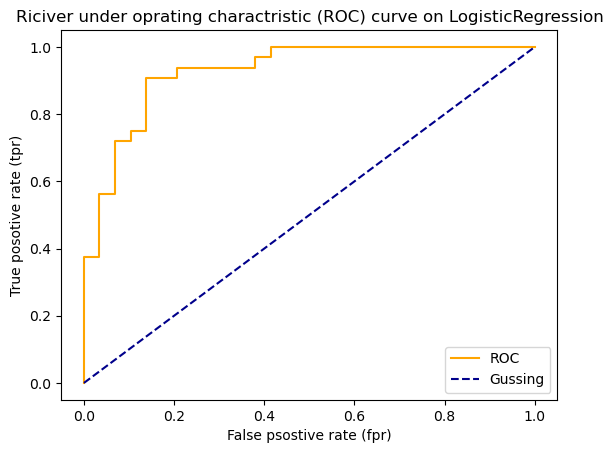

In [31]:
# Ploting roc_curve on LogisticRegression
def plot_roc_curve1(fpr1, tpr1):
    plt.plot(fpr1, tpr1, color="Orange", label="ROC")
    plt.plot([0,1], [0,1], color="Darkblue", linestyle="--" ,label="Gussing")
    plt.xlabel("False psostive rate (fpr)")
    plt.ylabel("True posotive rate (tpr)")
    plt.title("Riciver under oprating charactristic (ROC) curve on LogisticRegression")
    plt.legend()
    plt.show()
plot_roc_curve1(fpr1, tpr1)

In [23]:
# roc_curve on RandomForrest
fpr2, tpr2, tresholds2 = roc_curve(y_test, y_probs_positive2)
fpr2

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.03448276, 0.03448276, 0.03448276,
       0.06896552, 0.06896552, 0.13793103, 0.13793103, 0.17241379,
       0.17241379, 0.20689655, 0.20689655, 0.37931034, 0.44827586,
       0.55172414, 0.62068966, 0.72413793, 0.93103448, 1.        ])

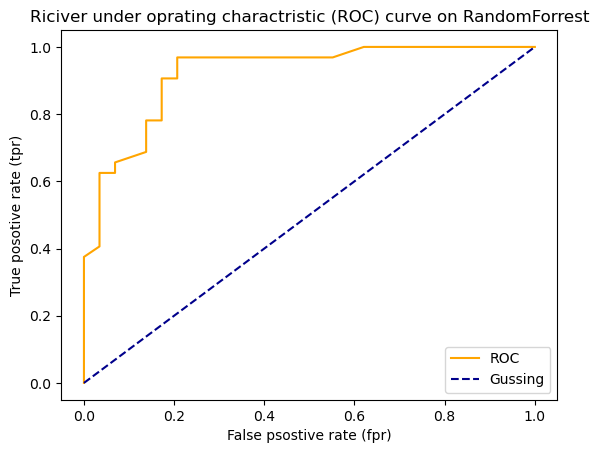

In [32]:
# Ploting roc_curve on RandomForrest
def plot_roc_curve1(fpr2, tpr2):
    plt.plot(fpr2, tpr2, color="Orange", label="ROC")
    plt.plot([0,1], [0,1], color="Darkblue", linestyle="--" ,label="Gussing")
    plt.xlabel("False psostive rate (fpr)")
    plt.ylabel("True posotive rate (tpr)")
    plt.title("Riciver under oprating charactristic (ROC) curve on RandomForrest")
    plt.legend()
    plt.show()
plot_roc_curve1(fpr2, tpr2)

In [26]:
# roc_curve on KNN
fpr3, tpr3, tresholds3 = roc_curve(y_test, y_probs_positive3)
fpr3

array([0.        , 0.        , 0.        , 0.        , 0.13793103,
       0.20689655, 0.31034483, 0.55172414, 0.68965517, 0.82758621,
       0.89655172, 0.96551724, 1.        ])

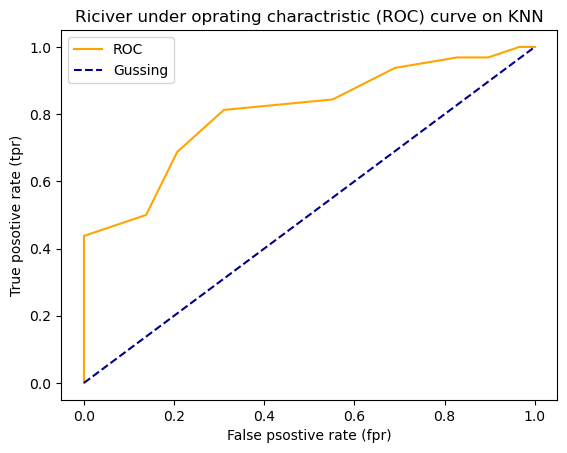

In [33]:
# Ploting roc_curve on KNN
def plot_roc_curve1(fpr3, tpr3):
    plt.plot(fpr3, tpr3, color="Orange", label="ROC")
    plt.plot([0,1], [0,1], color="Darkblue", linestyle="--" ,label="Gussing")
    plt.xlabel("False psostive rate (fpr)")
    plt.ylabel("True posotive rate (tpr)")
    plt.title("Riciver under oprating charactristic (ROC) curve on KNN")
    plt.legend()
    plt.show()
plot_roc_curve1(fpr3, tpr3)

In [28]:
# roc_auc_score
# roc_auc_score on LogisticRegression
roc_auc_score(y_test, y_probs_positive1)

0.9267241379310345

In [29]:
# roc_auc_score on RandomForrest
roc_auc_score(y_test, y_probs_positive2)

0.9207974137931034

In [30]:
# roc_auc_score on KNN
roc_auc_score(y_test, y_probs_positive3)

0.806573275862069

### Because our LogisticRegression model has an accuresy of over 88% in Score, over 82% in cross_val_score and over 92.6% roc_auc_score and has the highest accuresy so we use it as our main model for experments.

In [8]:
model = models.get("LogisticRegression")

In [9]:
# Making predection by a real data instances on our model
lis = []
elements = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal']
for i in elements:
    entere = float(input(f"Please enter your information about {i}: "))
    lis.append(entere)
np_array = np.array(lis)
predection = model.predict(np_array.reshape(1,-1))
if predection == 0:
    print("The test is Negative! Patient don't have Heart disease!")
elif predection == 1:
    print("The test is Positive! Patient has Heart disease!")
else:
    print("There is a problem with the system! Please check completly and try again!")

Please enter your information about age:  57
Please enter your information about sex:  1
Please enter your information about cp:  0
Please enter your information about trestbps:  130
Please enter your information about chol:  131
Please enter your information about fbs:  0
Please enter your information about restecg:  1
Please enter your information about thalach:  115
Please enter your information about exang:  1
Please enter your information about oldpeak:  1.2
Please enter your information about slope:  1
Please enter your information about ca:  1
Please enter your information about thal:  3


The test is Negative! Patient don't have Heart disease!


C:\Users\Mustafa akbari\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [16]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


## Saving our Trained models

In [10]:
for name, model in models.items():
    pickle.dump(model, open(f"{name}", "wb"))